# Notebook 04 — Decoupled Knowledge Distillation (DKD)

Classical KD couples two types of knowledge — target class knowledge (TCKD) and non-target class knowledge (NCKD) — into a single KL divergence term. This suppresses NCKD when the teacher is highly confident, limiting dark knowledge transfer. DKD (Zhao et al., CVPR 2022) decouples these into independently weighted terms, allowing each to contribute fully.

$$\mathcal{L}_{\text{DKD}} = \alpha \cdot \mathcal{L}_{\text{TCKD}} + \beta \cdot \mathcal{L}_{\text{NCKD}}$$

**Teacher:** 72.95% &nbsp;|&nbsp; **Baseline:** 67.97% &nbsp;|&nbsp; **Classical KD (T=4):** 69.02%

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE  = '/content/drive/MyDrive/kd_project'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEACHER_CKPT = f'{CKPT_DIR}/teacher_resnet110.pth'
assert os.path.exists(TEACHER_CKPT), \
    f'Teacher checkpoint not found at {TEACHER_CKPT}. Run Notebook 01 first.'

print('Drive mounted.')
print(f'Teacher checkpoint found: {TEACHER_CKPT}')

Mounted at /content/drive
Drive mounted.
Teacher checkpoint found: /content/drive/MyDrive/kd_project/checkpoints/teacher_resnet110.pth


## 2. Environment Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU.')

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition


## 3. Data Loading

Identical transforms to all previous notebooks.

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                               download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR100(root='./data', train=False,
                                               download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128,
                                            shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128,
                                            shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')

100%|██████████| 169M/169M [00:06<00:00, 26.5MB/s]


Train samples : 50,000
Test samples  : 10,000


## 4. Model Architecture

Same ResNet implementation as all previous notebooks.

In [4]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super(ResNet_CIFAR, self).__init__()
        self.in_channels = 16
        self.conv1   = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2  = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3  = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(64 * block.expansion, num_classes)
        self._init_weights()
    def _make_layer(self, block, out_ch, num_blocks, stride):
        layers = []
        for s in [stride] + [1]*(num_blocks-1):
            layers.append(block(self.in_channels, out_ch, s))
            self.in_channels = out_ch
        return nn.Sequential(*layers)
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out)
        out = self.avgpool(out); out = torch.flatten(out, 1)
        return self.fc(out)

def ResNet110(num_classes=100): return ResNet_CIFAR(BasicBlock, [18,18,18], num_classes)
def ResNet20(num_classes=100):  return ResNet_CIFAR(BasicBlock, [3, 3, 3],  num_classes)

print('Architecture defined.')

Architecture defined.


## 5. Load Teacher

Teacher loaded from Drive and frozen. Same as Notebook 03.

In [5]:
teacher = ResNet110(num_classes=100).to(device)
teacher.load_state_dict(torch.load(TEACHER_CKPT, map_location=device))
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

print(f'Teacher loaded and frozen — {sum(p.numel() for p in teacher.parameters())/1e6:.2f}M parameters.')

Teacher loaded and frozen — 1.74M parameters.


## 6. DKD Loss Function

Classical KD's KL divergence term implicitly couples two knowledge types. When the teacher is highly confident on the correct class, the non-target knowledge (NCKD) gets suppressed — precisely when it should contribute most.

DKD separates the loss into two independently weighted terms:
- **TCKD** — how confident is the teacher on the correct class
- **NCKD** — what the teacher thinks about all the wrong classes (the dark knowledge)

By giving NCKD its own weight $\beta$, it can contribute fully regardless of teacher confidence.

In [6]:
def dkd_loss(student_logits, teacher_logits, labels, T, alpha, beta):
    """
    Decoupled Knowledge Distillation loss (Zhao et al., CVPR 2022).

    Args:
        student_logits : raw student output (batch_size x num_classes)
        teacher_logits : raw teacher output (batch_size x num_classes)
        labels         : ground truth hard labels (batch_size,)
        T              : temperature for softening distributions
        alpha          : weight for TCKD (target class knowledge)
        beta           : weight for NCKD (non-target class knowledge)
    """
    # Softened probabilities
    student_softmax = F.softmax(student_logits / T, dim=1)
    teacher_softmax = F.softmax(teacher_logits / T, dim=1)

    # One-hot encode the target labels
    batch_size  = labels.shape[0]
    num_classes = student_logits.shape[1]
    target_mask = torch.zeros(batch_size, num_classes, device=labels.device)
    target_mask.scatter_(1, labels.unsqueeze(1), 1.0)

    # ── TCKD: target class knowledge distillation ─────────────────────────────
    # Focuses on how confident the teacher is about the correct class
    # Binary distribution over (correct class, all others collapsed)
    student_target = (student_softmax * target_mask).sum(dim=1, keepdim=True)
    teacher_target = (teacher_softmax * target_mask).sum(dim=1, keepdim=True)
    student_tckd   = torch.cat([student_target, 1 - student_target], dim=1)
    teacher_tckd   = torch.cat([teacher_target, 1 - teacher_target], dim=1)
    tckd_loss      = F.kl_div(
        torch.log(student_tckd + 1e-8),
        teacher_tckd,
        reduction='batchmean'
    ) * (T ** 2)

    # ── NCKD: non-target class knowledge distillation ─────────────────────────
    # Focuses on relationships among ALL incorrect classes (the dark knowledge)
    # Renormalize distributions over non-target classes only
    non_target_mask    = 1.0 - target_mask
    student_non_target = student_softmax * non_target_mask
    teacher_non_target = teacher_softmax * non_target_mask

    # Renormalize so non-target probabilities sum to 1
    student_non_target = student_non_target / (student_non_target.sum(dim=1, keepdim=True) + 1e-8)
    teacher_non_target = teacher_non_target / (teacher_non_target.sum(dim=1, keepdim=True) + 1e-8)

    nckd_loss = F.kl_div(
        torch.log(student_non_target + 1e-8),
        teacher_non_target,
        reduction='batchmean'
    ) * (T ** 2)

    # ── Hard loss + combined DKD loss ──────────────────────────────────────────
    hard_loss = F.cross_entropy(student_logits, labels)
    return hard_loss + alpha * tckd_loss + beta * nckd_loss


print('DKD loss function defined.')

DKD loss function defined.


## 7. Training and Evaluation Functions

In [7]:
def train_dkd_epoch(student, teacher, loader, optimizer, T, alpha, beta, device):
    student.train()
    teacher.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            teacher_logits = teacher(images)
        student_logits = student(images)
        loss = dkd_loss(student_logits, teacher_logits, labels, T, alpha, beta)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (student_logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(dim=1) == labels).sum().item()
            total   += images.size(0)
    return 100.0 * correct / total


print('Functions defined.')

Functions defined.


## 8. Training Configuration

We use the recommended hyperparameters from Zhao et al. (2022): T=4, alpha=1.0, beta=1.0. Same optimizer and LR schedule as all previous notebooks.

In [8]:
NUM_EPOCHS    = 100
LEARNING_RATE = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4

# DKD hyperparameters from Zhao et al. (2022)
T     = 4      # Temperature — same optimal value found in Notebook 03
ALPHA = 1.0    # Weight for TCKD
BETA  = 1.0    # Weight for NCKD — independently weighted unlike classical KD

print(f'Epochs       : {NUM_EPOCHS}')
print(f'Temperature  : {T}')
print(f'Alpha (TCKD) : {ALPHA}')
print(f'Beta  (NCKD) : {BETA}')

Epochs       : 100
Temperature  : 4
Alpha (TCKD) : 1.0
Beta  (NCKD) : 1.0


## 9. Training

In [9]:
student   = ResNet20(num_classes=100).to(device)
optimizer = optim.SGD(student.parameters(), lr=LEARNING_RATE,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=0.1)
CKPT_PATH = f'{CKPT_DIR}/dkd_student.pth'

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc   = 0.0
start_time = time.time()

print(f'Training DKD on {device} for {NUM_EPOCHS} epochs  |  T={T}, alpha={ALPHA}, beta={BETA}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_dkd_epoch(
        student, teacher, train_loader, optimizer, T, ALPHA, BETA, device)
    test_acc = evaluate(student, test_loader, device)
    scheduler.step()

    train_losses.append(train_loss);  train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(student.state_dict(), CKPT_PATH)

    elapsed    = (time.time() - start_time) / 60
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
          f'Train Acc: {train_acc:.2f}%  '
          f'Test Acc: {test_acc:.2f}%  '
          f'Best: {best_acc:.2f}%  '
          f'LR: {current_lr:.4f}  '
          f'Elapsed: {elapsed:.1f}m')

elapsed = (time.time() - start_time) / 60
print('=' * 70)
print(f'Training complete — Best: {best_acc:.2f}% — Time: {elapsed:.1f}m')
print(f'Checkpoint: {CKPT_PATH}')

Training DKD on cuda for 100 epochs  |  T=4, alpha=1.0, beta=1.0
Epoch [  1/100]  Train Acc: 9.61%  Test Acc: 15.55%  Best: 15.55%  LR: 0.1000  Elapsed: 0.1m
Epoch [  2/100]  Train Acc: 24.83%  Test Acc: 27.12%  Best: 27.12%  LR: 0.1000  Elapsed: 0.2m
Epoch [  3/100]  Train Acc: 34.68%  Test Acc: 32.53%  Best: 32.53%  LR: 0.1000  Elapsed: 0.2m
Epoch [  4/100]  Train Acc: 41.97%  Test Acc: 39.42%  Best: 39.42%  LR: 0.1000  Elapsed: 0.3m
Epoch [  5/100]  Train Acc: 46.46%  Test Acc: 39.06%  Best: 39.42%  LR: 0.1000  Elapsed: 0.4m
Epoch [  6/100]  Train Acc: 48.86%  Test Acc: 46.35%  Best: 46.35%  LR: 0.1000  Elapsed: 0.4m
Epoch [  7/100]  Train Acc: 51.27%  Test Acc: 44.80%  Best: 46.35%  LR: 0.1000  Elapsed: 0.5m
Epoch [  8/100]  Train Acc: 53.02%  Test Acc: 45.06%  Best: 46.35%  LR: 0.1000  Elapsed: 0.6m
Epoch [  9/100]  Train Acc: 54.15%  Test Acc: 45.56%  Best: 46.35%  LR: 0.1000  Elapsed: 0.7m
Epoch [ 10/100]  Train Acc: 55.22%  Test Acc: 47.93%  Best: 47.93%  LR: 0.1000  Elapsed: 0

## 10. Training Curves

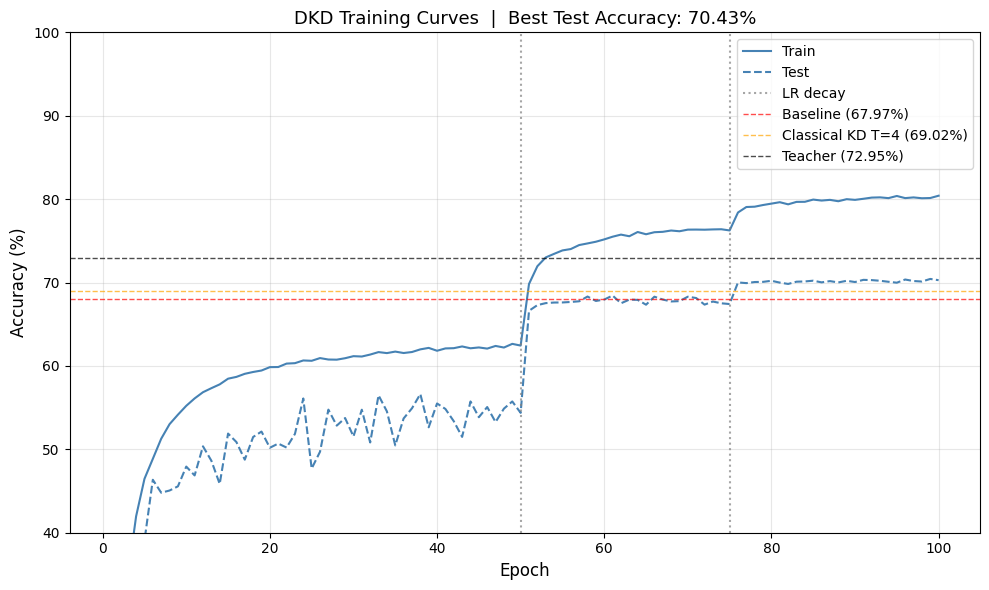

Plot saved to Drive.


In [10]:
TEACHER_ACC  = 72.95
BASELINE_ACC = 67.97
KD_ACC       = 69.02  # Best Classical KD result from Notebook 03

fig, ax = plt.subplots(figsize=(10, 6))
epochs_range = range(1, NUM_EPOCHS + 1)

ax.plot(epochs_range, train_accs, label='Train', color='steelblue', linewidth=1.5)
ax.plot(epochs_range, test_accs,  label='Test',  color='steelblue', linewidth=1.5, linestyle='--')
ax.axvline(x=50, color='gray', linestyle=':', alpha=0.7, label='LR decay')
ax.axvline(x=75, color='gray', linestyle=':', alpha=0.7)
ax.axhline(y=BASELINE_ACC, color='red',    linestyle='--', linewidth=1,
           alpha=0.7, label=f'Baseline ({BASELINE_ACC:.2f}%)')
ax.axhline(y=KD_ACC,       color='orange', linestyle='--', linewidth=1,
           alpha=0.7, label=f'Classical KD T=4 ({KD_ACC:.2f}%)')
ax.axhline(y=TEACHER_ACC,  color='black',  linestyle='--', linewidth=1,
           alpha=0.7, label=f'Teacher ({TEACHER_ACC:.2f}%)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'DKD Training Curves  |  Best Test Accuracy: {best_acc:.2f}%', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([40, 100])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/dkd_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive.')

## 11. Final Results — DKD vs Classical KD vs Baseline

In [11]:
best_student = ResNet20(num_classes=100).to(device)
best_student.load_state_dict(torch.load(CKPT_PATH, map_location=device))
final_acc = evaluate(best_student, test_loader, device)

print('=' * 55)
print('  DKD vs Classical KD — Comparison')
print('=' * 55)
print(f'  Teacher (ResNet-110)     : {TEACHER_ACC:.2f}%')
print(f'  Student baseline (no KD) : {BASELINE_ACC:.2f}%')
print(f'  Classical KD (T=4)       : {KD_ACC:.2f}%  (+{KD_ACC - BASELINE_ACC:.2f}%)')
print(f'  DKD                      : {final_acc:.2f}%  (+{final_acc - BASELINE_ACC:.2f}%)')
print(f'  DKD improvement over KD  : +{final_acc - KD_ACC:.2f}%')
print(f'  Remaining gap to teacher : {TEACHER_ACC - final_acc:.2f}%')
print('=' * 55)
print(f'  Checkpoint: {CKPT_PATH}')

  DKD vs Classical KD — Comparison
  Teacher (ResNet-110)     : 72.95%
  Student baseline (no KD) : 67.97%
  Classical KD (T=4)       : 69.02%  (+1.05%)
  DKD                      : 70.43%  (+2.46%)
  DKD improvement over KD  : +1.41%
  Remaining gap to teacher : 2.52%
  Checkpoint: /content/drive/MyDrive/kd_project/checkpoints/dkd_student.pth
